<a href="https://colab.research.google.com/github/RCDS13/PI-JP-4SEM/blob/main/etl_transito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive', force_remount=True)
!ls "/content/drive/MyDrive/PI_JP"
!pip install rpy2
%load_ext rpy2.ipython

In [ ]:
%%R

library(dplyr)
library(stringi)
library(tidyverse)

In [ ]:
%%R

path <- "/content/drive/MyDrive/PI_JP/"

# PADRONIZACAO E LEITURA
df1 <- read_delim(paste0(path, "datatran2021.csv"), delim = ";", locale = locale(encoding = "latin1")) %>% mutate(across(any_of(c("latitude", "longitude")), as.character))
df2 <- read_delim(paste0(path, "datatran2022.csv"), delim = ";", locale = locale(encoding = "latin1")) %>% mutate(across(any_of(c("latitude", "longitude")), as.character))
df3 <- read_delim(paste0(path, "datatran2023.csv"), delim = ";", locale = locale(encoding = "latin1")) %>% mutate(across(any_of(c("latitude", "longitude")), as.character))
df4 <- read_delim(paste0(path, "datatran2024.csv"), delim = ";", locale = locale(encoding = "latin1")) %>% mutate(across(any_of(c("latitude", "longitude")), as.character))
df5 <- read_delim(paste0(path, "datatran2025.csv"), delim = ";", locale = locale(encoding = "latin1")) %>% mutate(across(any_of(c("latitude", "longitude")), as.character))

# JUNCAO DE TABELAS
df_final <- bind_rows(df1, df2, df3, df4, df5)

# SALVAR TABELA FINAL
write_excel_csv(df_final, paste0(path, "dataset_final.csv"), delim = ";")


In [ ]:
%%R
# VERIFICA LINHAS DUPLICADAS

total_original <- nrow(df_final)

total_unicas <- nrow(distinct(df_final))

duplicados <- total_original - total_unicas

print(paste("Registros duplicados encontrados:", duplicados))

In [6]:
%%R

# CARREGA TABELA FINAL

dados <- read.csv2("/content/drive/MyDrive/PI_JP/dataset_final.csv", fileEncoding="UTF-8")

# REMOCAO DE ACENTOS
dados_sp <- dados %>%
  filter(uf == "SP") %>%
  mutate(across(where(is.character), ~ stri_trans_general(., "Latin-ASCII")))

# SALVAMENTO USANDO FILE ENCONDING LATIN1 PRA COMTABILIDADE
write.csv2(dados_sp,
           "/content/drive/MyDrive/PI_JP/dataset_final_SP.csv",
           row.names = FALSE,
           fileEncoding = "latin1")

In [ ]:
%%R

# ESCOPO DO DICINARIO DE VARIAVEIS
dicionario <- data.frame(
  Variavel = names(dados),
  Tipo_R = sapply(dados, class),
  Descricao = "",
  Valores = "",
  stringsAsFactors = FALSE
)

# VISUALIZACAO
print(dicionario)

# SALVA NO DRIVE
write.csv2(dicionario,
           "/content/drive/MyDrive/PI_JP/dicionario_variaveis.csv",
           row.names = FALSE,
           fileEncoding = "UTF-8")

In [7]:
%%R

library(lubridate)
library(hms)

# ALTERANDO TIPO DE DADOS
dados_sp$data_hora <- ymd_hms(paste(dados_sp$data_inversa, dados_sp$horario))
dados_sp$latitude <- as.numeric(gsub(",", ".", dados_sp$latitude))
dados_sp$longitude <- as.numeric(gsub(",", ".", dados_sp$longitude))
dados_sp$km <- as.numeric(gsub(",", ".", dados_sp$km))

write.csv2(dados_sp,
           "/content/drive/MyDrive/PI_JP/dataset_final_SP.csv",
           row.names = FALSE,
           fileEncoding = "latin1")

str(dados_sp)

'data.frame':	18668 obs. of  31 variables:
 $ id                    : int  331730 332015 332229 332289 332397 332695 332889 332955 332969 333016 ...
 $ data_inversa          : chr  "2021-01-01" "2021-01-02" "2021-01-03" "2021-01-03" ...
 $ dia_semana            : chr  "sexta-feira" "sabado" "domingo" "domingo" ...
 $ horario               : chr  "05:30:00" "10:20:00" "14:40:00" "18:10:00" ...
 $ uf                    : chr  "SP" "SP" "SP" "SP" ...
 $ br                    : int  116 116 153 116 381 116 116 116 116 116 ...
 $ km                    : num  453 363 266 230 83 ...
 $ municipio             : chr  "REGISTRO" "MIRACATU" "MARILIA" "SAO PAULO" ...
 $ causa_acidente        : chr  "Reacao tardia ou ineficiente do condutor" "Frear bruscamente" "Condutor Dormindo" "Acessar a via sem observar a presenca dos outros veiculos" ...
 $ tipo_acidente         : chr  "Tombamento" "Tombamento" "Saida de leito carrocavel" "Colisao lateral" ...
 $ classificacao_acidente: chr  "Com Vitimas Ferid


Attaching package: ‘hms’

The following object is masked from ‘package:lubridate’:

    hms



In [9]:
%%R

# MÉTODOS ESTATÍSTICOS - MORTES E CAUSA DO ACIDENTE

moda_causa <- as.character(names(sort(table(dados_sp$causa_acidente), decreasing = TRUE)[1]))
cat("moda de causa do acidente:", moda_causa, "\n")

tab_causa <- table(dados_sp$causa_acidente)
cat("tabela de frequências de causas do acidente:\n", tab_causa, "\n")

prop_causa <- prop.table(table(dados_sp$causa_acidente))
cat("tabela de frequências de causas do acidente (proporção):\n", prop_causa, "\n")


media_mortos <- mean(dados_sp$mortos, na.rm = TRUE)
cat("média de óbitos:", media_mortos, "\n")

mediana_mortos <- median(dados_sp$mortos)
cat("mediana de óbitos:", mediana_mortos, "\n")

medap_mortos <- mean(dados_sp$mortos, trim = 0.1)
cat("média aparada de óbitos:", medap_mortos, "\n")

desvpad_mortos <- sd(dados_sp$mortos)
cat("desvio padrão de óbitos:", desvpad_mortos, "\n")

var_mortos <- var(dados_sp$mortos)
cat("variancia de mortes:", var_mortos, "\n")

aiq_mortos <- IQR(dados_sp$mortos)
cat("interquartílica de mortes:", aiq_mortos, "\n")

moda de causa do acidente: Reacao tardia ou ineficiente do condutor 
tabela de frequências de causas do acidente:
 802 79 9 110 81 80 42 170 14 3168 38 504 68 368 1244 21 374 21 104 65 5 30 906 47 15 79 4 285 54 2 19 12 1 145 2 32 25 11 762 20 173 1390 2 7 171 22 22 1 3 3 236 156 5 47 313 76 12 3973 1 3 33 2 17 1 19 749 152 46 38 7 173 997 
tabela de frequências de causas do acidente (proporção):
 0.04296122 0.004231841 0.0004821084 0.005892436 0.004338976 0.004285408 0.002249839 0.009106492 0.0007499464 0.1697022 0.002035569 0.02699807 0.003642597 0.01971288 0.0666381 0.00112492 0.02003428 0.00112492 0.005571031 0.003481894 0.000267838 0.001607028 0.04853225 0.002517677 0.000803514 0.004231841 0.0002142704 0.01526677 0.002892651 0.0001071352 0.001017784 0.0006428112 5.35676e-05 0.007767302 0.0001071352 0.001714163 0.00133919 0.0005892436 0.04081851 0.001071352 0.009267195 0.07445897 0.0001071352 0.0003749732 0.00916006 0.001178487 0.001178487 5.35676e-05 0.0001607028 0.0001607028 0.01

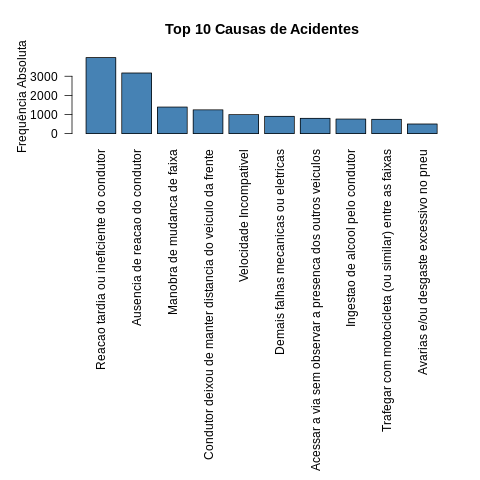

In [10]:
%%R

causas_contagem <- sort(table(dados_sp$causa_acidente), decreasing = TRUE)
top_10_causas <- causas_contagem[1:10]
par(mar = c(24, 5, 4, 2))

barplot(top_10_causas,
        las = 2,
        main = "Top 10 Causas de Acidentes",
        col = "steelblue",
        ylab = "Frequência Absoluta")


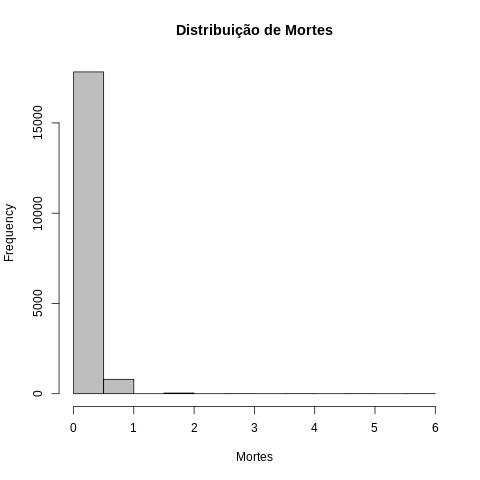

In [ ]:
%%R

hist(dados_sp$mortos, main="Distribuição de Mortes", xlab="Mortes", col="gray")

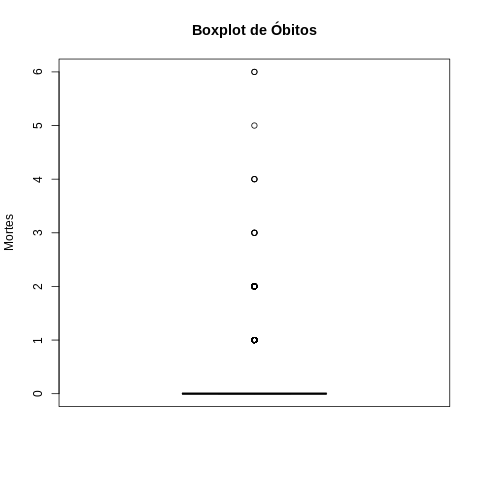

In [11]:
%%R

# Visualiza a posição, dispersão e os pontos discrepantes (outliers)
boxplot(dados_sp$mortos, main="Boxplot de Óbitos", col="lightblue", ylab="Mortes")

In [ ]:
%%R

# CALCULO DE HORARIO COM MAIS ACIDENTES
hora_pico <- dados_sp %>%
  mutate(hora = hour(data_hora)) %>%
  count(hora, sort = TRUE) %>%
  rename(Total_Acidentes = n)

acidente_municipio <- dados_sp %>%
  count(municipio, sort = TRUE) %>%
  rename(Quant_Acidentes = n)

print(acidente_municipio)
print(hora_pico)